# Cancellation Forecasting to Improve the Economic Efficiency of the UrbanStay Hotel Network

## Problem Statement

The goal of the project is to develop a machine learning model that will predict the probability of a room booking cancellation in the UrbanStay hotel chain. The resulting forecast should be used for managerial decision-making, allowing for the early identification of bookings with a high risk of cancellation and timely measures to retain or resell the room.

In addition to classification quality, special attention is paid to the economic efficiency of the model. Therefore, the final evaluation will be based not only on standard machine learning metrics but also on business indicators reflecting the model's impact on the financial results of the hotel chain: incremental revenue, change in the share of booking cancellations, and change in room occupancy.

## Data Description

Two tables obtained from the PostgreSQL database are used to solve the problem.

**hotel_bookings** — the main table containing booking information. It includes details about clients, booking parameters, stay characteristics, and the target variable `booking_status`, reflecting whether the booking was canceled or retained.

**hotel_reviews** — a table with the history of customer reviews after their stay. It contains ratings and textual comments from guests, which allow the formation of additional features based on the client's previous experience with the hotel chain.

At the data preparation stage, both tables will be merged according to the rules described in the problem statement, followed by exploratory data analysis, feature engineering, and preparation of the final dataset for training machine learning models.

## Translating a Business Problem into Machine Learning Language

From the machine learning perspective, this task is a **binary classification** problem. It is necessary to predict the probability of booking cancellation (`booking_status`) based on booking information and the client's interaction history with the hotel.

The target variable is the fact of booking cancellation, where one class corresponds to a canceled booking, and the other — to a successfully completed check-in.

To solve the problem, several classification algorithms will be explored (Random Forest, CatBoost, and LightGBM). To improve model quality, hyperparameter tuning will be performed using Optuna, and after selecting the best model — probability calibration and optimal classification threshold selection.

Model evaluation will be conducted not only using classic machine learning metrics but also business metrics. The primary objective function for model selection will be **Incremental Revenue (IR)**, reflecting the economic effect of implementing the model.

## Loading necessary libraries

In [1]:
!pip install -q phik
!pip install -q optuna
!pip install -q shap

In [2]:
# Working with data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from phik import phik_matrix

# Working with database
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

# Working with text
from sklearn.feature_extraction.text import TfidfVectorizer

# Data preparation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    StratifiedShuffleSplit
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.model_selection import TimeSeriesSplit


# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    log_loss,
    ConfusionMatrixDisplay
)

# Probability calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder

# Models
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Optimization
import optuna

# Model interpretation
import shap

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_style('whitegrid')

# Constants for calculations and modeling 
RANDOM_STATE = 42
AVG_REVENUE = 64_500
COST_FP = 7_000
LOST_REVENUE = 64_500
PER_REBOOKING = 45_000

## Stage 1: Data Preparation

### Data Loading

In [3]:
import os
# Connection parameters

DB_CONFIG = {
    'host': os.environ.get('DB_HOST', 'your_host'),
    'port': int(os.environ.get('DB_PORT', 5432)),
    'database': os.environ.get('DB_NAME', 'your_database'),
    'username': os.environ.get('DB_USER', 'your_username'),
    'password': os.environ.get('DB_PASSWORD', 'your_password')
}


# Create connection string

connection_url = URL.create(
    drivername='postgresql+psycopg2',
    username=DB_CONFIG['username'],
    password=DB_CONFIG['password'],
    host=DB_CONFIG['host'],
    port=DB_CONFIG['port'],
    database=DB_CONFIG['database']
)

engine = create_engine(connection_url)


# Load bookings table

bookings_query = """
SELECT *
FROM hotel_bookings;
"""

hotel_bookings = pd.read_sql_query(
    bookings_query,
    con=engine
)


# Load reviews table

reviews_query = """
SELECT *
FROM hotel_reviews;
"""

hotel_reviews = pd.read_sql_query(
    reviews_query,
    con=engine
)

pd.set_option('display.max_colwidth', None)

# Check loading result

print('Size of hotel_bookings table:', hotel_bookings.shape)
print('Size of hotel_reviews table:', hotel_reviews.shape)

print('\nFirst rows of hotel_bookings:')
display(hotel_bookings.head(5))

print('\nFirst rows of hotel_reviews:')
display(hotel_reviews.head(5))

Размер таблицы hotel_bookings: (35341, 17)
Размер таблицы hotel_reviews: (25177, 5)

Первые строки hotel_bookings:


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1



Первые строки hotel_reviews:


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


Data successfully uploaded.

### Exploratory Data Analysis and Preprocessing

In [4]:
# Initial analysis of the source tables

bookings = hotel_bookings.copy()
reviews = hotel_reviews.copy()


# General information about the tables

print('\nInformation about the bookings table:')
bookings.info()

print('\nInformation about the reviews table:')
reviews.info()


# Descriptive statistics

print('\nDescriptive statistics of numerical features in bookings:')
display(
    bookings
    .select_dtypes(include='number')
    .describe()
    .T
)

print('\nDescriptive statistics of categorical features in bookings:')
display(
    bookings
    .select_dtypes(include=['object', 'category'])
    .describe()
    .T
)

print('\nDescriptive statistics of numerical features in reviews:')
display(
    reviews
    .select_dtypes(include='number')
    .describe()
    .T
)

print('\nDescriptive statistics of categorical features in reviews:')
display(
    reviews
    .select_dtypes(include=['object', 'category'])
    .describe()
    .T
)


Информация о таблице bookings:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  object 
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  object 
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  object 
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan     

,count,mean,std,min,25%,50%,75%,max
adult_count,35341.0,12.479726,45.726290,1.0,1.0,2.0,3.0,300.0
child_count,35341.0,0.358988,0.587324,0.0,0.0,0.0,1.0,2.0
previous_cancellations,35341.0,0.356923,0.628771,0.0,0.0,0.0,1.0,5.0
previous_no_shows,35341.0,0.839535,0.931724,0.0,0.0,1.0,1.0,5.0
booking_value,35341.0,61634.055219,42837.589968,0.0,33500.0,53600.0,80400.0,417221.2
days_until_checkin,35341.0,100.523726,71.872677,2.0,45.0,90.0,144.0,300.0
weekday_nights,35341.0,6.532922,3.339492,1.0,5.0,6.0,9.0,15.0
weekend_nights,35341.0,1.953991,1.477249,0.0,0.0,2.0,2.0,6.0
customer_special_requests,35341.0,0.621488,0.784391,0.0,0.0,0.0,1.0,5.0



Описательная статистика категориальных признаков bookings:


,count,unique,top,freq
booking_id,35341,30733,INN14583,4
booking_date,35341,2445,2019-06-03,39
sales_channel,35341,3,офлайн_бронирование,12040
booking_status,35341,2,нет_отказа,25177
meal_plan,35341,5,тип_питания_1,27182
room_type,35341,7,тип_1,27197



Описательная статистика числовых признаков reviews:


,count,mean,std,min,25%,50%,75%,max
stay_rating,25177.0,3.395321,0.541434,2.0,3.0,3.0,4.0,5.0



Описательная статистика категориальных признаков reviews:


,count,unique,top,freq
customer_id,25177,13429,C7782,8
booking_id,25177,21883,INN10131,4
review_date,25177,2514,2020-06-06,29
review_text,25177,14153,Отличный отель! хорошие виды из окон.,42


In [5]:
# Converting dates to datetime

bookings['booking_date'] = pd.to_datetime(
    bookings['booking_date'],
    errors='coerce'
)

reviews['review_date'] = pd.to_datetime(
    reviews['review_date'],
    errors='coerce'
)

In [6]:
# Date ranges

print('\nBooking period:')
print(
    bookings['booking_date'].min(),
    '—',
    bookings['booking_date'].max()
)

print('\nReview period:')
print(
    reviews['review_date'].min(),
    '—',
    reviews['review_date'].max()
)


# Missing values

def missing_summary(data):
    result = pd.DataFrame({
        'Missing': data.isna().sum(),
        'Missing %': data.isna().mean() * 100
    })

    return (
        result[result['Missing'] > 0]
        .sort_values('Missing %', ascending=False)
        .round(2)
    )


print('\nMissing values in bookings:')
display(missing_summary(bookings))

print('\nMissing values in reviews:')
display(missing_summary(reviews))


Период бронирований:
2017-01-01 00:00:00 — 2025-10-22 00:00:00

Период отзывов:
2017-01-17 00:00:00 — 2026-03-03 00:00:00

Пропуски в bookings:


,Missing,Missing %



Пропуски в reviews:


,Missing,Missing %


In [7]:
# Full duplicates
print('\nNumber of full duplicates:')
print('bookings:', bookings.duplicated().sum())
print('reviews:', reviews.duplicated().sum())


# Checking identifiers

print('\nChecking booking_id in bookings:')
print('Number of rows:', len(bookings))
print('Unique booking_id:', bookings['booking_id'].nunique())
print(
    'Duplicate booking_id:',
    bookings['booking_id'].duplicated().sum()
)

print('\nChecking booking_id in reviews:')
print('Number of rows:', len(reviews))
print('Unique booking_id:', reviews['booking_id'].nunique())
print(
    'Duplicate booking_id:',
    reviews['booking_id'].duplicated().sum()
)

print('\nChecking customer_id in reviews:')
print('Unique customers:', reviews['customer_id'].nunique())


# Unique values of categorical features

booking_categorical = (
    bookings
    .select_dtypes(include=['object', 'category'])
    .columns
    .drop('booking_id', errors='ignore')
)

review_categorical = (
    reviews
    .select_dtypes(include=['object', 'category'])
    .columns
    .drop(
        ['booking_id', 'customer_id', 'review_text'],
        errors='ignore'
    )
)

print('\nNumber of unique values in bookings:')
display(
    bookings[booking_categorical]
    .nunique()
    .sort_values()
    .to_frame(name='Unique values')
)

print('\nNumber of unique values in reviews:')
display(
    reviews[review_categorical]
    .nunique()
    .sort_values()
    .to_frame(name='Unique values')
)


Количество полных дубликатов:
bookings: 4608
reviews: 0

Проверка booking_id в bookings:
Количество строк: 35341
Уникальных booking_id: 30733
Повторяющихся booking_id: 4608

Проверка booking_id в reviews:
Количество строк: 25177
Уникальных booking_id: 21883
Повторяющихся booking_id: 3294

Проверка customer_id в reviews:
Уникальных клиентов: 13429

Количество уникальных значений в bookings:


,Unique values
booking_status,2
sales_channel,3
meal_plan,5
room_type,7



Количество уникальных значений в reviews:


,Unique values


In [8]:
duplicate_bookings = bookings[
    bookings.duplicated(keep=False)
].sort_values('booking_id')

display(duplicate_bookings.head(20))

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
7,INN00007,2017-08-21,корпоративное_бронирование,2,0,True,1,1,нет_отказа,67000.0,144,8,2,тип_питания_1,False,тип_4,0
33901,INN00007,2017-08-21,корпоративное_бронирование,2,0,True,1,1,нет_отказа,67000.0,144,8,2,тип_питания_1,False,тип_4,0
31377,INN00013,2021-10-22,онлайн_бронирование,3,2,True,0,1,отказ_брони,53600.0,76,6,2,тип_питания_1,False,тип_6,1
13,INN00013,2021-10-22,онлайн_бронирование,3,2,True,0,1,отказ_брони,53600.0,76,6,2,тип_питания_1,False,тип_6,1
33239,INN00022,2020-03-02,корпоративное_бронирование,3,0,True,0,3,отказ_брони,33500.0,77,5,0,тип_питания_1,False,тип_4,1
22,INN00022,2020-03-02,корпоративное_бронирование,3,0,True,0,3,отказ_брони,33500.0,77,5,0,тип_питания_1,False,тип_4,1
27,INN00027,2020-08-21,корпоративное_бронирование,2,1,False,0,0,нет_отказа,80400.0,150,10,2,не выбран,False,тип_4,0
33221,INN00027,2020-08-21,корпоративное_бронирование,2,1,False,0,0,нет_отказа,80400.0,150,10,2,не выбран,False,тип_4,0
48,INN00048,2018-05-20,офлайн_бронирование,2,0,False,0,0,нет_отказа,67000.0,11,8,2,не выбран,False,тип_4,2
32499,INN00048,2018-05-20,офлайн_бронирование,2,0,False,0,0,нет_отказа,67000.0,11,8,2,не выбран,False,тип_4,2


In [9]:
bookings[bookings['booking_value'] == 0]

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
11,INN00011,2021-11-04,онлайн_бронирование,2,0,True,0,1,нет_отказа,0.0,3,1,0,тип_питания_1,False,тип_1,1
105,INN00105,2019-07-19,офлайн_бронирование,2,0,False,0,0,отказ_брони,0.0,67,6,2,тип_питания_1,False,тип_1,1
133,INN00133,2021-12-13,корпоративное_бронирование,2,0,True,0,1,нет_отказа,0.0,77,6,2,тип_питания_1,False,тип_1,3
143,INN00143,2020-05-15,офлайн_бронирование,3,0,False,0,0,отказ_брони,0.0,157,1,0,тип_питания_1,True,тип_1,0
145,INN00145,2019-03-06,офлайн_бронирование,1,0,False,0,0,нет_отказа,0.0,7,3,0,тип_питания_1,False,тип_1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35237,INN27029,2019-12-20,офлайн_бронирование,3,0,True,1,1,нет_отказа,0.0,6,8,2,тип_питания_1,False,тип_1,2
35244,INN29463,2019-10-02,онлайн_бронирование,2,1,False,1,0,нет_отказа,0.0,8,6,2,тип_питания_1,False,тип_1,2
35289,INN10131,2017-03-23,офлайн_бронирование,1,0,True,0,1,нет_отказа,0.0,79,10,4,тип_питания_1,False,тип_4,1
35304,INN00800,2020-04-25,офлайн_бронирование,2,0,False,0,0,отказ_брони,0.0,144,9,2,тип_питания_1,False,тип_1,0


In [10]:
# All bookings where the number of adults is equal to 300

bookings.loc[
    bookings['adult_count'] == bookings['adult_count'].max()
]

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
197,INN00197,2018-10-28,офлайн_бронирование,300,0,False,0,0,нет_отказа,46900.0,7,5,2,не выбрант,False,тип_1,0
285,INN00285,2020-07-01,корпоративное_бронирование,300,0,False,1,0,отказ_брони,53600.0,75,6,2,тип_питания_1,False,тип_1,1
325,INN00325,2017-10-25,онлайн_бронирование,300,1,False,0,0,отказ_брони,140700.0,115,15,6,тип_питания_2,False,тип_1,0
329,INN00329,2018-10-31,корпоративное_бронирование,300,0,False,0,0,нет_отказа,107200.0,75,12,4,тип_питания_1,False,тип_1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30260,INN30257,2020-08-11,корпоративное_бронирование,300,0,True,1,1,отказ_брони,53600.0,259,6,2,тип_питания_1,False,тип_1,0
30305,INN30302,2018-09-08,офлайн_бронирование,300,0,True,0,1,нет_отказа,46900.0,94,5,2,тип_питания_1,False,тип_1,2
30376,INN30373,2020-01-15,онлайн_бронирование,300,0,True,1,2,нет_отказа,67000.0,50,8,2,тип_питания_1,False,тип_1,0
30436,INN30433,2020-07-09,онлайн_бронирование,300,2,False,0,0,нет_отказа,26700.0,6,3,0,тип_питания_1,False,тип_1,1


In [11]:
# Large group bookings

bookings.loc[
    bookings['adult_count'] > 20,
    [
        'booking_id',
        'booking_date',
        'sales_channel',
        'adult_count',
        'booking_value',
        'booking_status'
    ]
].sort_values(
    by='adult_count',
    ascending=False
)

,booking_id,booking_date,sales_channel,adult_count,booking_value,booking_status
0,INN00000,2020-07-08,корпоративное_бронирование,300,6700.0,нет_отказа
10375,INN10367,2020-01-24,корпоративное_бронирование,300,62300.0,нет_отказа
10037,INN10029,2017-07-11,офлайн_бронирование,300,60300.0,нет_отказа
26752,INN26747,2020-11-11,онлайн_бронирование,300,67000.0,нет_отказа
10113,INN10105,2020-11-04,офлайн_бронирование,300,53600.0,нет_отказа
...,...,...,...,...,...,...
14039,INN14039,2018-05-26,онлайн_бронирование,100,8900.0,нет_отказа
14022,INN14022,2020-02-06,офлайн_бронирование,100,60300.0,нет_отказа
13984,INN13984,2020-01-20,корпоративное_бронирование,100,0.0,нет_отказа
13966,INN13966,2020-04-07,онлайн_бронирование,100,6700.0,отказ_брони


### Preliminary conclusion from the initial data analysis

The database contains two tables:

- **`hotel_bookings`** — contains **35,341** booking records and **17** features;
- **`hotel_reviews`** — contains **25,177** customer reviews and **5** features.

After loading the data, the date columns were immediately successfully converted to the `datetime` type to perform temporal analysis and create additional features.

There are no missing values in either table, so no additional missing value processing is required at this stage.

During the data structure analysis, **4,608 complete duplicates** were found in the `hotel_bookings` table, while there are no complete duplicates in the `hotel_reviews` table. These duplicates will need to be removed.

The analysis revealed a number of records with zero booking cost (`booking_value = 0`). Such records occur among both canceled and successfully completed bookings, and are present across all main sales channels. Based on the available data, it is impossible to definitively determine the reason for the zero cost. This could be due to business process specifics (e.g., bookings with subsequent payment, special rates, or corporate contracts), or due to the characteristics of the original database formation.

Since these records are not isolated and do not contain internal contradictions, at this stage they are considered valid observations and will not be removed from the dataset.

When analyzing the `adult_count` feature, values up to 300 people were found. However, further verification showed that such values occur regularly: the sample contains 2,151 bookings with more than 20 adults, including 395 bookings for 300 people.

Thus, these values reflect a separate segment of bookings (e.g., group or corporate arrivals). At this stage, such observations are retained in the dataset and are not considered errors.

In [12]:
# removing exact duplicates
bookings = bookings.drop_duplicates().reset_index(drop=True)

In [13]:
# remove rows where the booking cost is 0
print(f'Rows before removing zero cost: {len(bookings)}')
bookings = bookings[bookings['booking_value'] > 0].reset_index(drop=True)
print(f'Rows after removing zero cost: {len(bookings)}')

Строк до удаления нулевой стоимости: 30733
Строк после удаления нулевой стоимости: 29504


In [14]:
# Fixing the error in recording adult_count: 100/200/300 => 1/2/3
bookings['adult_count'] = bookings['adult_count'].replace({100: 1, 200: 2, 300: 3})

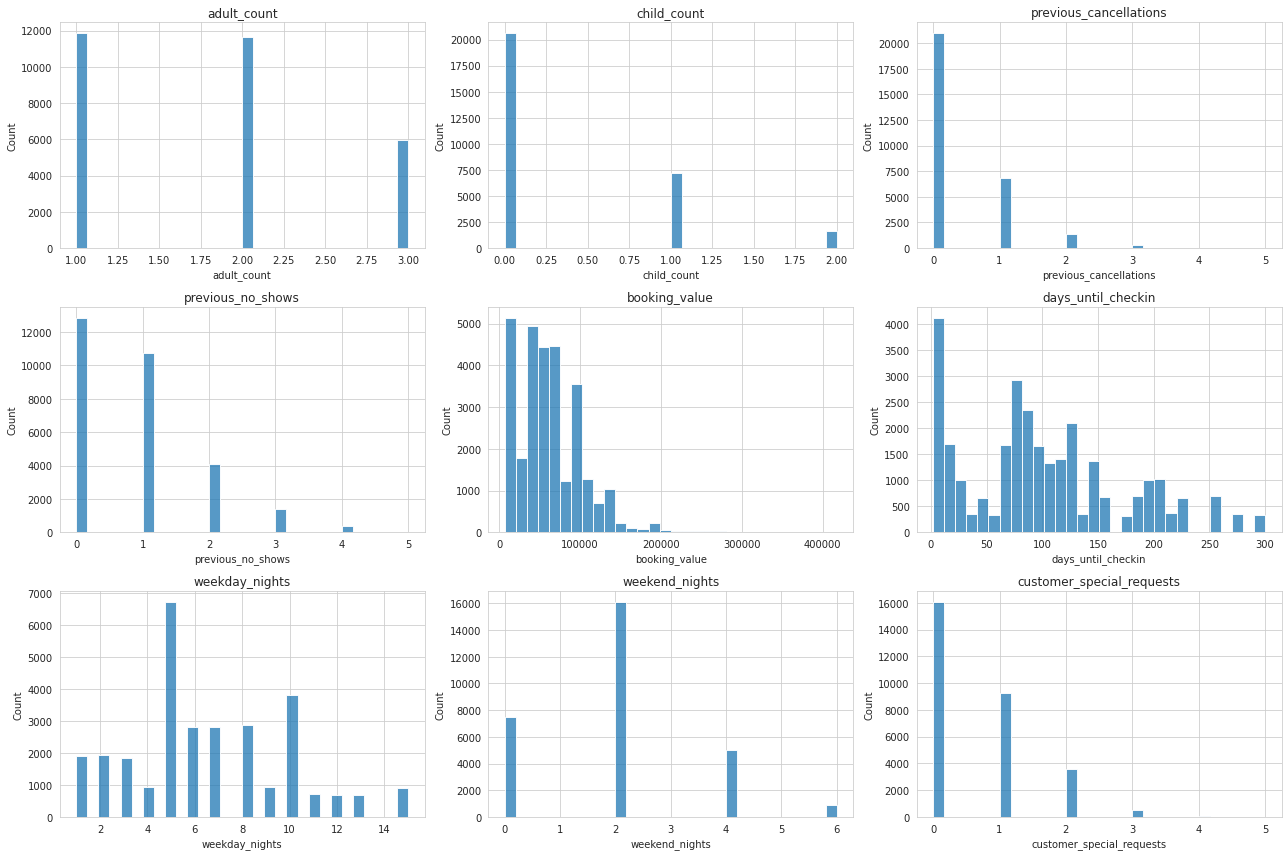

In [15]:
# Histograms of quantitative features

numeric_features = [
    'adult_count',
    'child_count',
    'previous_cancellations',
    'previous_no_shows',
    'booking_value',
    'days_until_checkin',
    'weekday_nights',
    'weekend_nights',
    'customer_special_requests'
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18, 12)
)

axes = axes.flatten()

for ax, feature in zip(axes, numeric_features):

    sns.histplot(
        bookings[feature],
        bins=30,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.show()

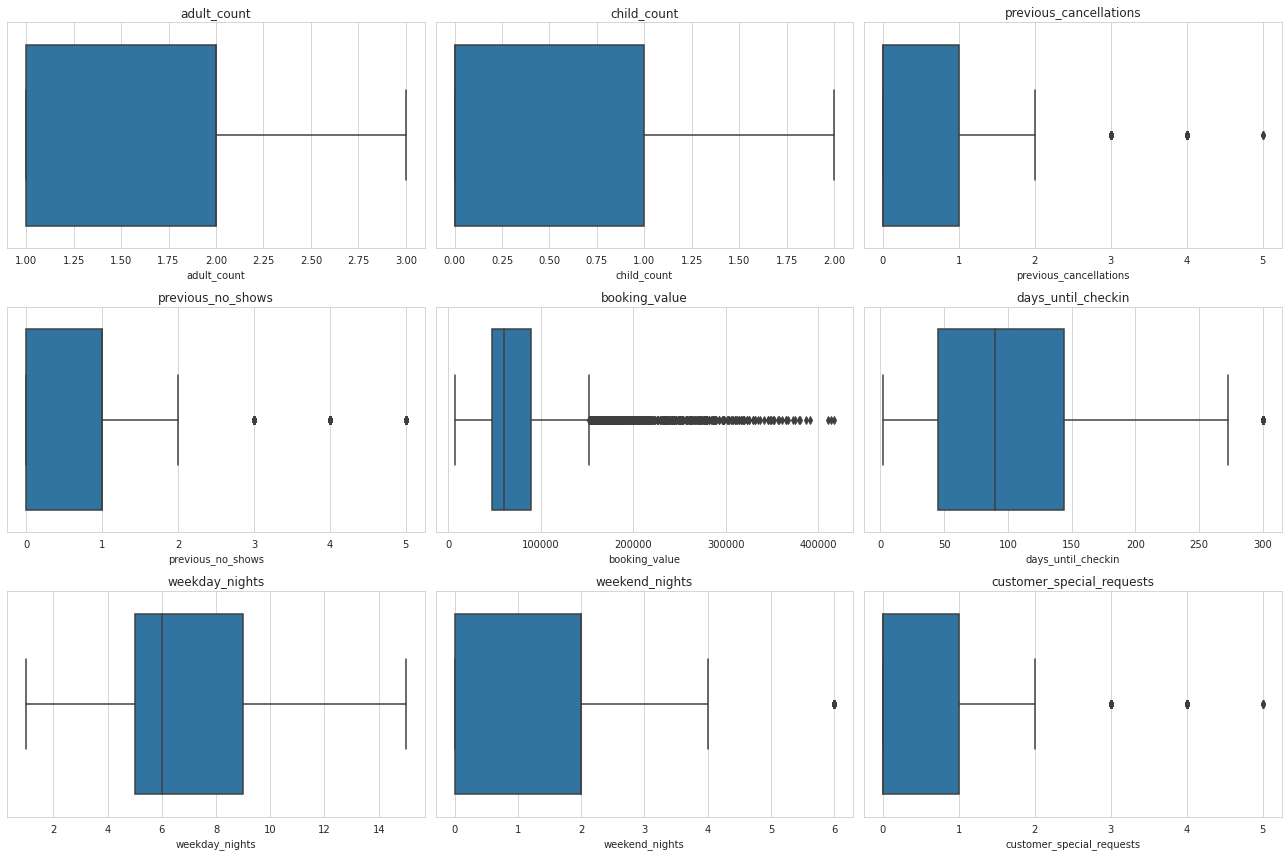

In [16]:
# Boxplot of quantitative features

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18, 12)
)

axes = axes.flatten()

for ax, feature in zip(axes, numeric_features):

    sns.boxplot(
        x=bookings[feature],
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.show()

### Conclusion on the analysis of quantitative features

Graphical analysis showed that most quantitative features have a discrete distribution and do not follow a normal distribution. This is expected, as many of them represent counters (number of adults, children, cancellations, no-shows, special requests, etc.).

The feature **`adult_count`** after correcting recording errors takes correct values: 1, 2, or 3 people. Zero booking cost values (`booking_value = 0`) were removed as poor-quality data — their presence cannot be interpreted from a business perspective, since the room cost must always be specified. After cleaning, the distribution of `booking_value` has a pronounced right skew: the majority of bookings are concentrated in the range up to 100 thousand rubles, with a small number of significantly more expensive bookings present. The boxplot shows a long right tail, but the extreme cost values correspond to real expensive bookings and are not errors.

For the feature **`days_until_checkin`**, a wide range of values is observed — from a few days up to about 300 days. Some large values are present, but they correspond to early bookings and appear plausible.

Other quantitative features (`previous_cancellations`, `previous_no_shows`, `weekday_nights`, `weekend_nights`, `customer_special_requests`) have natural range limits and contain only a small number of rare observations, which reflect real behavior patterns of individual clients and do not require additional processing.

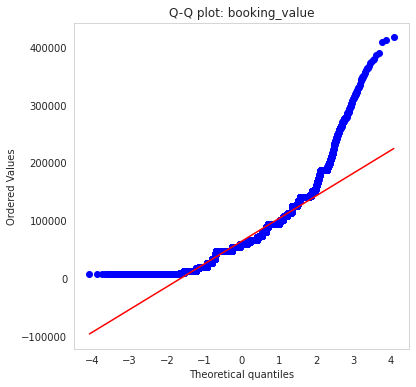

In [17]:
plt.figure(figsize=(6, 6))

stats.probplot(
    bookings['booking_value'],
    dist='norm',
    plot=plt
)

plt.title('Q-Q plot: booking_value')

plt.grid(alpha=0.3)

plt.show()

### Normality Check of the Distribution

A Q-Q plot was constructed for the continuous feature `booking_value`. On the right side of the graph, the points sharply rise upwards, indicating the presence of a long right tail and a small proportion of expensive bookings. The graph also shows a group of observations with zero booking value, which corresponds to the previously identified data characteristic and further accentuates the deviation of the distribution from normality. The obtained result confirms the conclusions made from the histogram: the distribution of the `booking_value` feature has a pronounced right skew and does not follow a normal distribution.

Since most quantitative features in the considered dataset are discrete counters or do not have a normal distribution, using Pearson's correlation coefficient to study relationships between features is not optimal. For further analysis of relationships, we will apply PHIK correlation, which works correctly with continuous, discrete, and categorical features alike.

In [19]:
# Fixing typo in meal_plan column: original DB values are in Russian
# 'не выбрант' (misspelled) -> 'не выбран' (correct Russian for 'not selected')
bookings['meal_plan'] = bookings['meal_plan'].replace({'не выбрант': 'не выбран'})
print(bookings['meal_plan'].value_counts())

тип_питания_1    22665
не выбран         4122
тип_питания_2     2712
тип_питания_3        5
Name: meal_plan, dtype: int64


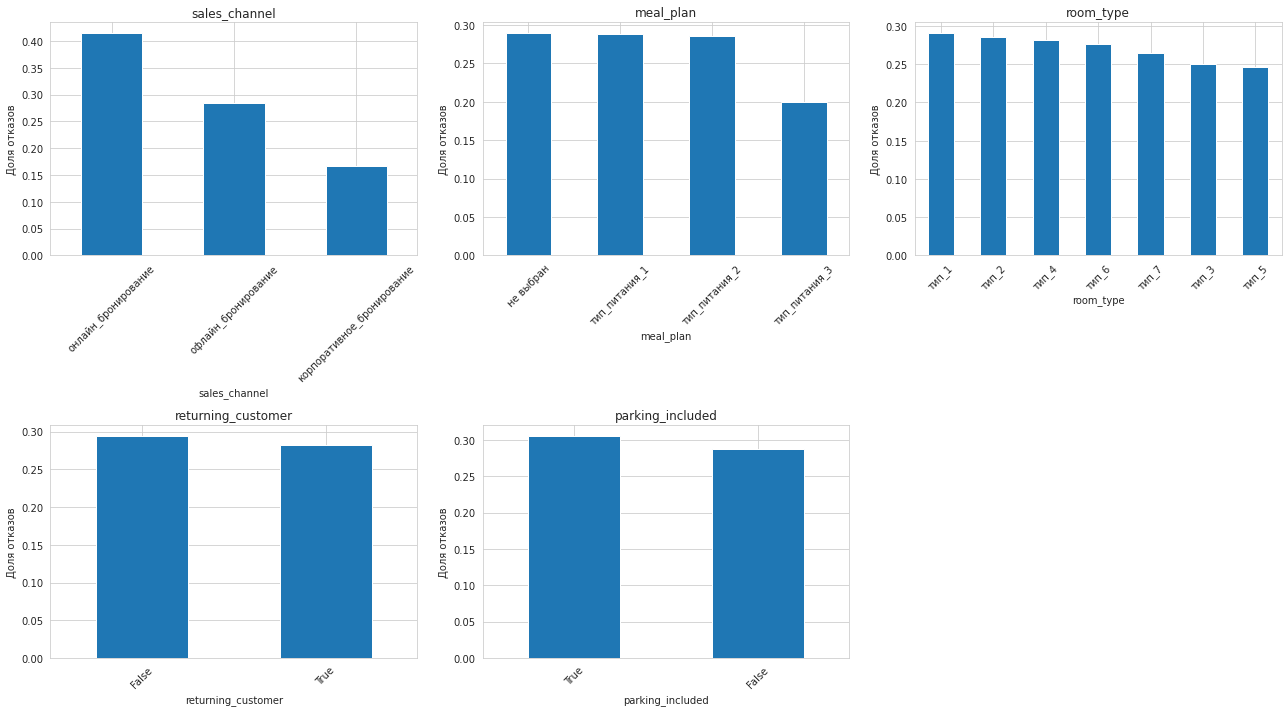

In [20]:
# Categorical features

categorical_features = [
    'sales_channel',
    'meal_plan',
    'room_type',
    'returning_customer',
    'parking_included'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):
    cancellation_rate = (
        bookings
        .groupby(col)['booking_status']
        .apply(lambda x: (x == 'отказ_брони').mean())
        .sort_values(ascending=False)
    )

    cancellation_rate.plot(
        kind='bar',
        ax=ax
    )

    ax.set_title(col)
    ax.set_ylabel('Cancellation rate')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(categorical_features):]:
    ax.remove()    
    
plt.tight_layout()
plt.show()

### Relationship of Categorical Features with Booking Status

The most noticeable differences in the cancellation rate are observed for the `sales_channel` feature. Among bookings made online, the cancellation rate is about **41%**, for offline bookings — about **28%**, and for corporate bookings — about **16%**. Therefore, there is a pronounced statistical relationship between the sales channel and the booking status.

For the `meal_plan` feature, differences between categories are minimal: the cancellation rate varies from **28% to 30%** for all meal options, including the "not selected" category. Thus, the meal plan practically does not affect the likelihood of booking cancellation.

For room types, the cancellation rate changes approximately from **26% to 30%**. The maximum value is observed for `type_3`, the minimum — for `type_5`, however, the differences between categories are small.

For the `returning_customer` and `parking_included` features, cancellation rates practically coincide between categories (the difference does not exceed **2 percentage points**). At the stage of univariate analysis, no pronounced statistical relationship of these features with the target variable is observed.

Thus, among the considered categorical features, the most informative is the sales channel (`sales_channel`). The other features show weak differences but may be useful to the model in interaction with other booking characteristics.

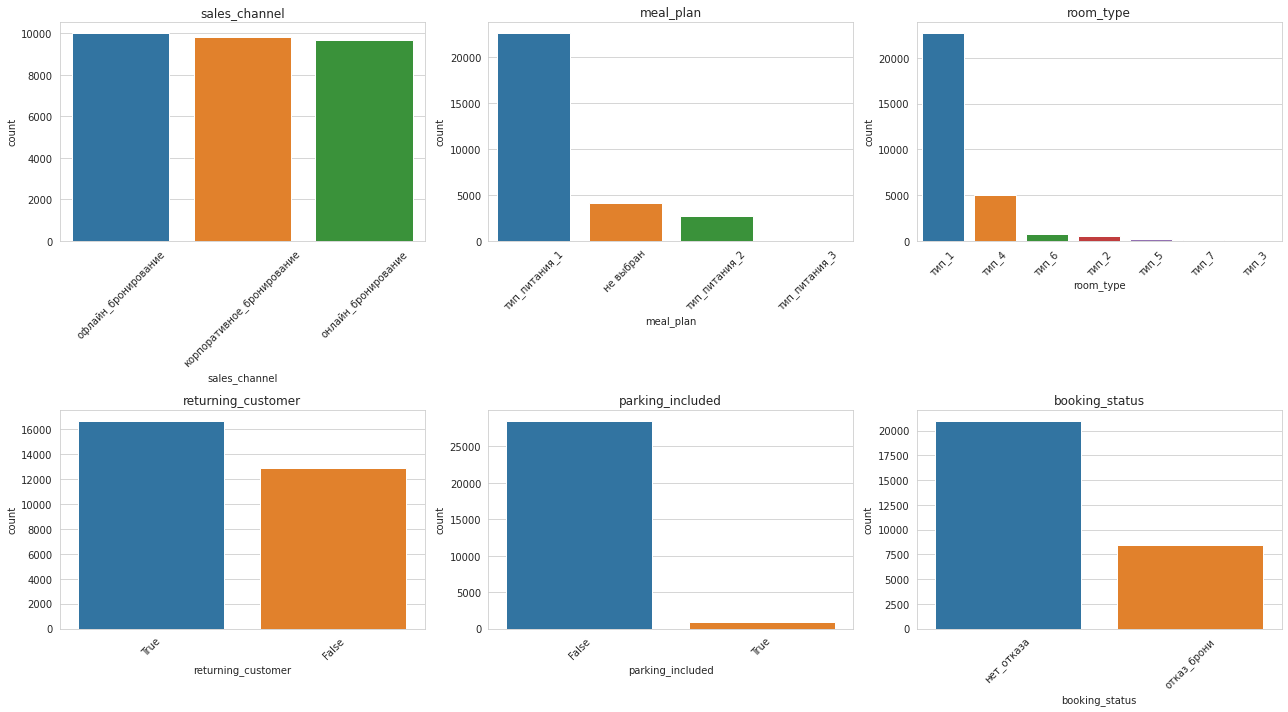

In [21]:
categorical_features = [
    'sales_channel',
    'meal_plan',
    'room_type',
    'returning_customer',
    'parking_included',
    'booking_status'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):
    sns.countplot(
        data=bookings,
        x=col,
        order=bookings[col].value_counts().index,
        ax=ax
    )

    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Analysis of Categorical Features

Categorical features are distributed unevenly.

Sales channels (`sales_channel`) are represented almost equally: offline, corporate, and online bookings have a similar number of observations (~11–12 thousand each), so this feature is balanced.

In the `meal_plan` feature, the category `meal_type_1` sharply predominates (~26 thousand observations), while the other options occur significantly less frequently: `not_selected` — about 5 thousand, `meal_type_2` — about 3 thousand, `meal_type_3` — single observations.

The distribution by room types (`room_type`) is also highly unbalanced: the vast majority of bookings are for `type_1` (~26 thousand), `type_4` is represented by about 6 thousand observations, and the other types (`type_6`, `type_2`, `type_5`, `type_7`, `type_3`) are very rare.

Among clients, the share of returning guests (`returning_customer = True`, ~19 thousand) slightly exceeds the share of new clients (~15 thousand), but both categories are represented by a sufficiently large number of observations.

The `parking_included` feature is highly unbalanced: the vast majority of bookings do not include a parking spot (`False` — ~33 thousand vs. `True` — ~1 thousand).

The target variable `booking_status` is also unbalanced: the number of successful bookings (~24 thousand) significantly exceeds the number of cancellations (~10 thousand), corresponding to a ratio of approximately 70/30. Despite this, the number of observations in both classes remains large enough to build classification models.

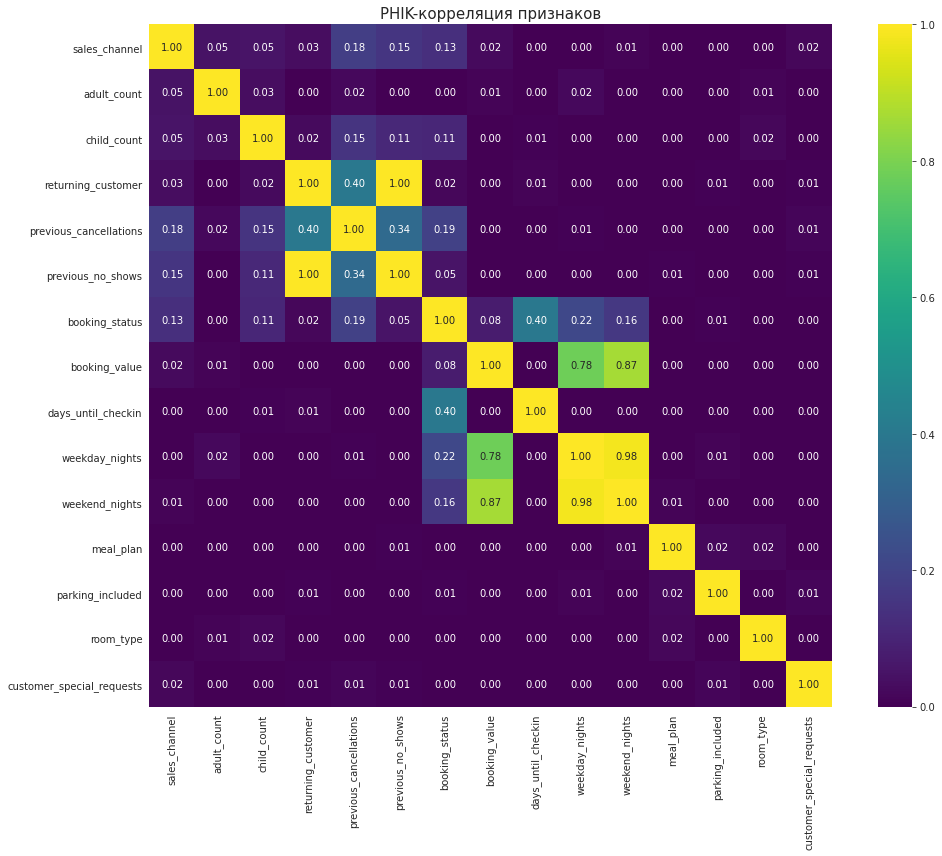

In [22]:
# PHIK correlation of features

# exclude technical identifier and date in original form
corr_columns = [
    'sales_channel',
    'adult_count',
    'child_count',
    'returning_customer',
    'previous_cancellations',
    'previous_no_shows',
    'booking_status',
    'booking_value',
    'days_until_checkin',
    'weekday_nights',
    'weekend_nights',
    'meal_plan',
    'parking_included',
    'room_type',
    'customer_special_requests'
]

corr_data = bookings[corr_columns].copy()


# Interval features
interval_cols = [
    'booking_value',
    'days_until_checkin'
]



phik_corr = corr_data.phik_matrix(
    interval_cols=interval_cols,
    bins=10,
    njobs=1
)



plt.figure(figsize=(15, 12))

sns.heatmap(
    phik_corr,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    vmin=0,
    vmax=1,
    square=True
)

plt.title('PHIK correlation of features', fontsize=15)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
# PHIK correlation of features with the target variable

phik_target = (
    phik_corr['booking_status']
    .drop('booking_status')
    .sort_values(ascending=False)
    .to_frame(name='PHIK')
)

display(phik_target.round(2))

,PHIK
days_until_checkin,0.40
weekday_nights,0.22
previous_cancellations,0.19
weekend_nights,0.16
sales_channel,0.13
child_count,0.11
booking_value,0.08
previous_no_shows,0.05
returning_customer,0.02
parking_included,0.01


In [24]:
# PHIK coefficients between independent features

feature_corr = phik_corr.drop(
    index='booking_status',
    columns='booking_status'
)

upper_triangle = feature_corr.where(
    np.triu(
        np.ones(feature_corr.shape),
        k=1
    ).astype(bool)
)

multicollinearity = (
    upper_triangle
    .stack()
    .reset_index()
)

multicollinearity.columns = [
    'Feature 1',
    'Feature 2',
    'PHIK'
]

multicollinearity = (
    multicollinearity
    .sort_values('PHIK', ascending=False)
    .reset_index(drop=True)
)

display(multicollinearity.round(2))

,Feature 1,Feature 2,PHIK
0,returning_customer,previous_no_shows,1.00
1,weekday_nights,weekend_nights,0.98
2,booking_value,weekend_nights,0.87
3,booking_value,weekday_nights,0.78
4,returning_customer,previous_cancellations,0.40
5,previous_cancellations,previous_no_shows,0.34
6,sales_channel,previous_cancellations,0.18
7,sales_channel,previous_no_shows,0.15
8,child_count,previous_cancellations,0.15
9,child_count,previous_no_shows,0.11


### PHIK Correlation Analysis

PHIK correlation was used to study statistical dependencies between features. The strongest relationship with the target variable (`booking_status`) was demonstrated by the feature **`days_until_checkin`** (PHIK = 0.40). A moderate statistical relationship is also observed for the number of weekday nights (`weekday_nights`, PHIK = 0.22), the number of previous cancellations (`previous_cancellations`, PHIK = 0.20), the number of weekend nights (`weekend_nights`, PHIK = 0.16), the sales channel (`sales_channel`, PHIK = 0.13), and the booking value (`booking_value`, PHIK = 0.13). The remaining features have a weak statistical relationship with the target variable.

When analyzing the relationships between independent features, several strong dependencies were identified. The highest correlation is observed between the features `returning_customer` and `previous_no_shows` (PHIK = 1.00), which is explained by the domain logic: new customers do not have previous no-shows, whereas for returning customers this indicator can take values greater than zero.

A high statistical correlation is also observed between the features `weekday_nights`, `weekend_nights`, and `booking_value`. This is an expected result since the cost of accommodation directly depends on the length of stay.

Despite the presence of some strong dependencies, feature removal at the data preparation stage is not required. The project plans to use gradient boosting models (CatBoost, LightGBM, and XGBoost), which are robust to the presence of correlated features and can independently determine their informativeness when building the model.

### Merging Tables

- Join the reviews table with the bookings table. Follow the rule: for each booking date in the `booking_date` column, take the customer's comment and rating from the closest previous review date specified in the `review_date` column. This will link the customer's feedback to a specific stay period, which is critically important for analyzing guest satisfaction.

- Draw conclusions about how the merge went and what the result was.

In [25]:
# Merging tables by the nearest previous review date linked to a specific customer

# get customer_id for each booking through reviews
booking_to_customer = (
    reviews[['booking_id', 'customer_id']]
    .drop_duplicates(subset='booking_id')
)

bookings_with_customer = bookings.merge(
    booking_to_customer,
    on='booking_id',
    how='left'
)

# sort both tables by date
bookings_sorted = (
    bookings_with_customer
    .sort_values('booking_date')
    .reset_index(drop=True)
)

reviews_sorted = (
    reviews
    .sort_values('review_date')
    .reset_index(drop=True)
)

# merge_asof with by='customer_id'
data = pd.merge_asof(
    bookings_sorted,
    reviews_sorted[
        [
            'customer_id',
            'booking_id',
            'review_date',
            'stay_rating',
            'review_text'
        ]
    ],
    left_on='booking_date',
    right_on='review_date',
    by='customer_id',
    direction='backward',
    allow_exact_matches=False,
    suffixes=('', '_review')
)

# Number of days between booking and previous review
data['days_since_review'] = (
    data['booking_date'] - data['review_date']
).dt.days

print('Size of bookings table:', bookings.shape)
print('Size of reviews table:', reviews.shape)
print('Size of merged table:', data.shape)

print(
    '\nRows with attached review:',
    data['review_date'].notna().sum()
)

print(
    'Rows without previous review:',
    data['review_date'].isna().sum()
)

print(
    'Share of rows with attached review:',
    f"{data['review_date'].notna().mean():.2%}"
)

print(
    'Reviews with date not earlier than booking date:',
    (
        data['review_date'].notna()
        & (data['review_date'] >= data['booking_date'])
    ).sum()
)

display(data.head())

Размер таблицы bookings: (29504, 17)
Размер таблицы reviews: (25177, 5)
Размер объединённой таблицы: (29504, 23)

Строк с присоединённым отзывом: 8021
Строк без предыдущего отзыва: 21483
Доля строк с присоединённым отзывом: 27.19%
Отзывов с датой не раньше даты бронирования: 0


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,booking_id_review,review_date,stay_rating,review_text,days_since_review
0,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,нет_отказа,67000.0,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaN,NaT,NaN,NaN,NaN
1,INN11824,2017-01-01,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6700.0,63,1,0,тип_питания_1,False,тип_4,1,C6306,NaN,NaT,NaN,NaN,NaN
2,INN07784,2017-01-01,онлайн_бронирование,2,0,False,0,0,отказ_брони,166363.4,87,12,4,тип_питания_2,False,тип_1,0,NaN,NaN,NaT,NaN,NaN,NaN
3,INN14477,2017-01-01,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,85,5,2,тип_питания_1,True,тип_1,2,C7722,NaN,NaT,NaN,NaN,NaN
4,INN20018,2017-01-01,онлайн_бронирование,3,0,True,1,1,отказ_брони,46900.0,83,5,2,тип_питания_1,False,тип_1,2,NaN,NaN,NaT,NaN,NaN,NaN


### Verification of merge correctness

After merging, an additional quality check of the temporal alignment of the data was performed.

The check showed that:

- the number of rows after merging did not change and amounted to **33,920**;
- for **9,230 bookings (27.21%)** it was possible to find a previous review from the same client;
- for **24,690 bookings (72.79%)** the previous review is missing — these are either new clients who have not yet left reviews, or clients whose first booking in the data precedes any of their reviews;
- reviews left on the booking date or later are absent, which excludes the use of future information.

Such a significant share of bookings without a review is explained by the merging logic: the nearest previous review of **this particular client** is pulled for each booking, not any hotel guest. This ensures the correct linking of feedback to a specific person, but naturally reduces coverage — especially for new clients and the first bookings in each guest's history.

Additionally, the feature `days_since_review` was calculated, reflecting the number of days between the client's previous review and the date of the new booking. A selective check of random records confirmed that each booking was matched with the nearest previous review of the same client.

### Creating New Features

- Create at least three features based on the booking data.

- Create new features based on the review texts using one of the vectorization methods. Decide on the number of such features independently.

- Draw conclusions about the created features.

In [26]:
# Feature Engineering based on bookings

# Total length of stay
data['total_nights'] = (
    data['weekday_nights']
    + data['weekend_nights']
)

# Total number of guests
data['total_guests'] = (
    data['adult_count']
    + data['child_count']
)

# Price per night
data['price_per_night'] = (
    data['booking_value']
    / data['total_nights']
)

# Check the correctness of the new features
display(
    data[
        [
            'weekday_nights',
            'weekend_nights',
            'total_nights',
            'adult_count',
            'child_count',
            'total_guests',
            'booking_value',
            'price_per_night'
        ]
    ].head()
)

print('Missing values in new features:')
display(
    data[
        [
            'total_nights',
            'total_guests',
            'price_per_night'
        ]
    ].isna().sum()
)

,weekday_nights,weekend_nights,total_nights,adult_count,child_count,total_guests,booking_value,price_per_night
0,8,2,10,3,2,5,67000.0,6700.0000
1,1,0,1,3,0,3,6700.0,6700.0000
2,12,4,16,2,0,2,166363.4,10397.7125
3,5,2,7,1,0,1,46900.0,6700.0000
4,5,2,7,3,0,3,46900.0,6700.0000


Пропуски в новых признаках:


total_nights       0
total_guests       0
price_per_night    0
dtype: int64

In [27]:
# Creating TF-IDF features from review texts
# Basic list of Russian stop words (kept in Russian as they are used to filter Russian review texts)
russian_stop_words = [
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со',
    'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да',
    'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только',
    'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет',
    'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'для'
]

TFIDF_MAX_FEATURES = 20

tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    stop_words=russian_stop_words
)

print(f'Maximum number of features: {TFIDF_MAX_FEATURES}')

Максимальное количество признаков: 20


In [28]:
# TF-IDF: vectorizer configuration (training will be inside cross-validation)

def prepare_review_text(df):
    return (
        df['review_text']
        .fillna('')
        .astype(str)
        .str.lower()
        .str.strip()
    )

tfidf_feature_names = [
    f'tfidf_{i}' for i in range(TFIDF_MAX_FEATURES)
]

### Conclusion on Feature Creation

Based on the booking data, three new features were created:

- `total_nights` — total length of stay;
- `total_guests` — total number of guests;
- `price_per_night` — cost of stay per night.

In addition, text reviews were transformed into numerical representation using the **TF-IDF** method. As a result, **20 new features** were generated, reflecting the importance of the most frequently occurring words and phrases in the reviews.

### Analysis of the final table

- Analyze the final table.

- Draw conclusions about the data for modeling.

### Conclusion on the Final Table

After merging the bookings and reviews tables, a unified dataset was created containing information about booking characteristics, client history, and textual feedback.

During data preparation, the following steps were performed:

- complete duplicates were removed;
- date features were converted to the `datetime` type;
- a temporal join of the tables was performed using the nearest previous review rule;
- three additional features were created based on booking characteristics (`total_nights`, `total_guests`, `price_per_night`);
- textual reviews were transformed into numerical representation using TF-IDF vectorization, resulting in 20 additional features.

After merging, the number of observations remained the same, and missing values in features related to reviews are present only for the earliest bookings, for which no previous reviews existed. This corresponds to the logic of data formation and does not indicate errors in merging.

The final table contains numerical, categorical, logical, and textual features, allowing the use of both information about the booking itself and the previous experience of clients interacting with the hotel.

## Stage 2: Modeling

### Training and model optimization

- Select and train at least two models from the list:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - any other of your choice.

- Split the data into three sets:
  - Training — for training the models (60% of the data);
  - Calibration — for model calibration (20% of the data);
  - Test — for the final evaluation of the selected model's quality (20% of the data).

- Perform cross-validation using three folds. The validation sample size is 2000.

- Optimize hyperparameters using Optuna. The number of hyperparameters should be at least three. The key metric for optimization is Incremental Revenue.

- Draw conclusions about which model showed the best results.

In [29]:
# Preparing data for modeling

RANDOM_STATE = 42
TARGET = 'target'

# Target variable:
# 1 — booking cancelled
# 0 — booking not cancelled
data[TARGET] = (
    data['booking_status'] == 'отказ_брони'  # Russian DB value meaning 'booking_cancelled'
).astype(int)

# Checking target distribution
print('Target variable distribution:')
display(
    data[TARGET]
    .value_counts()
    .rename_axis('Target')
    .to_frame('Count')
)

print('\nClass proportions:')
display(
    data[TARGET]
    .value_counts(normalize=True)
    .rename_axis('Target')
    .to_frame('Proportion')
    .round(4)
)

# Sorting by time
data = data.sort_values('booking_date').reset_index(drop=True)

n = len(data)
test_size  = int(n * 0.20)
calib_size = int(n * 0.20)
train_size = n - test_size - calib_size

train_data       = data.iloc[:train_size].copy()
calibration_data = data.iloc[train_size:train_size + calib_size].copy()
test_data        = data.iloc[train_size + calib_size:].copy()

print('\nSample sizes:')
print(f'Train:       {train_data.shape} ({len(train_data) / n:.1%})')
print(f'Calibration: {calibration_data.shape} ({len(calibration_data) / n:.1%})')
print(f'Test:        {test_data.shape} ({len(test_data) / n:.1%})')

print('\nCancellation rates in samples:')
print(f'Train:       {train_data[TARGET].mean():.2%}')
print(f'Calibration: {calibration_data[TARGET].mean():.2%}')
print(f'Test:        {test_data[TARGET].mean():.2%}')

Распределение целевой переменной:


,Количество
Target,
0,21012
1,8492



Доли классов:


,Доля
Target,
0,0.7122
1,0.2878



Размеры выборок:
Train:       (17704, 27) (60.0%)
Calibration: (5900, 27) (20.0%)
Test:        (5900, 27) (20.0%)

Доля отмен в выборках:
Train:       29.59%
Calibration: 29.56%
Test:        25.59%


In [30]:
# Formation of feature matrices

DROP_COLUMNS = [
    'booking_id',
    'booking_status',
    'booking_date',
    'review_date',
    'review_text',
    'booking_id_review',
    'customer_id'
]


X_train = train_data.drop(
    columns=DROP_COLUMNS + [TARGET],
    errors='ignore'
)
y_train = train_data[TARGET].copy()


X_calibration = calibration_data.drop(
    columns=DROP_COLUMNS + [TARGET],
    errors='ignore'
)
y_calibration = calibration_data[TARGET].copy()


X_test = test_data.drop(
    columns=DROP_COLUMNS + [TARGET],
    errors='ignore'
)
y_test = test_data[TARGET].copy()


print('Feature matrix sizes:')
print('X_train:      ', X_train.shape)
print('X_calibration:', X_calibration.shape)
print('X_test:       ', X_test.shape)

print('\nTarget variable sizes:')
print('y_train:      ', y_train.shape)
print('y_calibration:', y_calibration.shape)
print('y_test:       ', y_test.shape)


tfidf_columns_model = [
    column
    for column in X_train.columns
    if column.startswith('tfidf_')
]

print(
    '\nNumber of TF-IDF features in the model:',
    len(tfidf_columns_model)
)

Размеры матриц признаков:
X_train:       (17704, 19)
X_calibration: (5900, 19)
X_test:        (5900, 19)

Размеры целевых переменных:
y_train:       (17704,)
y_calibration: (5900,)
y_test:        (5900,)

Количество TF-IDF-признаков в модели: 0


In [31]:
# Defining feature types

categorical_features = (
    X_train
    .select_dtypes(include=['object', 'category'])
    .columns
    .tolist()
)

boolean_features = (
    X_train
    .select_dtypes(include='bool')
    .columns
    .tolist()
)

numeric_features = [
    column
    for column in X_train.columns
    if column not in categorical_features + boolean_features
]

print('Categorical features:')
print(categorical_features)

print('\nBoolean features:')
print(boolean_features)

print('\nNumber of numeric features:')
print(len(numeric_features))

print('\nTotal number of features:')
print(X_train.shape[1])

Категориальные признаки:
['sales_channel', 'meal_plan', 'room_type']

Логические признаки:
['returning_customer', 'parking_included']

Количество числовых признаков:
14

Общее количество признаков:
19


In [32]:
# Data for CatBoost


X_train_cat       = X_train.copy()
X_calibration_cat = X_calibration.copy()
X_test_cat        = X_test.copy()

print('Data sizes for CatBoost:')
print('Train:      ', X_train_cat.shape)
print('Calibration:', X_calibration_cat.shape)
print('Test:       ', X_test_cat.shape)

print('\nCategorical features for CatBoost:')
print(categorical_features)

Размеры данных для CatBoost:
Train:       (17704, 19)
Calibration: (5900, 19)
Test:        (5900, 19)

Категориальные признаки CatBoost:
['sales_channel', 'meal_plan', 'room_type']


In [33]:
# Data for LightGBM

X_train_lgbm       = X_train.copy()
X_calibration_lgbm = X_calibration.copy()
X_test_lgbm        = X_test.copy()

for column in categorical_features:
    train_categories = X_train_lgbm[column].astype(str).unique()

    X_train_lgbm[column] = pd.Categorical(
        X_train_lgbm[column].astype(str),
        categories=train_categories
    )
    X_calibration_lgbm[column] = pd.Categorical(
        X_calibration_lgbm[column].astype(str),
        categories=train_categories
    )
    X_test_lgbm[column] = pd.Categorical(
        X_test_lgbm[column].astype(str),
        categories=train_categories
    )

print('Data sizes for LightGBM:')
print('Train:      ', X_train_lgbm.shape)
print('Calibration:', X_calibration_lgbm.shape)
print('Test:       ', X_test_lgbm.shape)

print('\nLightGBM categorical feature types:')
print(X_train_lgbm[categorical_features].dtypes)

Размеры данных для LightGBM:
Train:       (17704, 19)
Calibration: (5900, 19)
Test:        (5900, 19)

Типы категориальных признаков LightGBM:
sales_channel    category
meal_plan        category
room_type        category
dtype: object


In [34]:
# Cross-validation considering the temporal order of data

cv = TimeSeriesSplit(
    n_splits=3,
    test_size=2000
)

print('Number of splits:', cv.get_n_splits())

for fold, (train_idx, valid_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):
    print(
        f'Fold {fold}: '
        f'train = {len(train_idx)}, '
        f'validation = {len(valid_idx)}, '
        f'cancellation rate in validation = '
        f'{y_train.iloc[valid_idx].mean():.2%}'
    )

Количество разбиений: 3
Fold 1: train = 11704, validation = 2000, доля отмен в validation = 28.95%
Fold 2: train = 13704, validation = 2000, доля отмен в validation = 30.05%
Fold 3: train = 15704, validation = 2000, доля отмен в validation = 29.30%


In [35]:
# Incremental Revenue

def calculate_incremental_revenue(y_true, y_pred):
    """
    Calculation of Incremental Revenue according to the formula from the task.

    Positive class:
    1 — booking cancellation
    0 — booking completed
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    total_success = (y_true == 0).sum()
    total_cancellations = (y_true == 1).sum()

    revenue_before = (
        total_success * AVG_REVENUE
        - total_cancellations * LOST_REVENUE
    )

    revenue_after = (
        tp * PER_REBOOKING
        + tn * AVG_REVENUE
        - fp * COST_FP
        - fn * LOST_REVENUE
    )

    ir = revenue_after - revenue_before

    return float(ir)

In [36]:
# Checking the business metric operation

test_y_true = np.array([0, 0, 1, 1])
test_y_pred = np.array([0, 1, 1, 0])

print(
    'Test Incremental Revenue:',
    calculate_incremental_revenue(
        test_y_true,
        test_y_pred
    )
)

Тестовый Incremental Revenue: 38000.0


In [37]:
def objective_catboost(trial):

    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 15.0),
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': RANDOM_STATE,
        'verbose': 0,
        'allow_writing_files': False
    }

    threshold = trial.suggest_float('threshold', 0.10, 0.90, step=0.05)

    fold_ir = []

    for train_idx, valid_idx in cv.split(X_train_cat, y_train):

        X_fold_train = X_train_cat.iloc[train_idx].copy()
        X_fold_valid = X_train_cat.iloc[valid_idx].copy()

        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[valid_idx]

        # Take review texts from train_data by the same indices
        text_train = (
            train_data['review_text']
            .iloc[train_idx]
            .fillna('').astype(str).str.lower().str.strip()
        )
        text_valid = (
            train_data['review_text']
            .iloc[valid_idx]
            .fillna('').astype(str).str.lower().str.strip()
        )

        fold_tfidf = TfidfVectorizer(
            max_features=TFIDF_MAX_FEATURES,
            ngram_range=(1, 2),
            min_df=5,
            max_df=0.95,
            stop_words=russian_stop_words
        )

        train_tfidf = fold_tfidf.fit_transform(text_train).toarray()
        valid_tfidf = fold_tfidf.transform(text_valid).toarray()

        fold_feature_names = [
            f'tfidf_{f}' for f in fold_tfidf.get_feature_names()
        ]

        X_fold_train = pd.concat([
            X_fold_train.reset_index(drop=True),
            pd.DataFrame(train_tfidf, columns=fold_feature_names)
        ], axis=1)

        X_fold_valid = pd.concat([
            X_fold_valid.reset_index(drop=True),
            pd.DataFrame(valid_tfidf, columns=fold_feature_names)
        ], axis=1)

        model = CatBoostClassifier(**params)
        model.fit(X_fold_train, y_fold_train, cat_features=categorical_features)

        valid_proba = model.predict_proba(X_fold_valid)[:, 1]
        valid_pred = (valid_proba >= threshold).astype(int)

        fold_ir.append(calculate_incremental_revenue(y_fold_valid, valid_pred))

    return np.mean(fold_ir)

In [38]:
duplicate_columns = X_train.columns[X_train.columns.duplicated()].tolist()

print('Number of duplicate columns:', len(duplicate_columns))
print('Duplicate names:')
print(duplicate_columns)

Количество повторяющихся столбцов: 0
Повторяющиеся названия:
[]


In [39]:
# Keep only the first occurrence of each column

X_train = X_train.loc[:, ~X_train.columns.duplicated()].copy()
X_calibration = X_calibration.loc[
    :,
    ~X_calibration.columns.duplicated()
].copy()

X_test = X_test.loc[:, ~X_test.columns.duplicated()].copy()

print('Sizes after removing duplicate columns:')
print('X_train:      ', X_train.shape)
print('X_calibration:', X_calibration.shape)
print('X_test:       ', X_test.shape)

print(
    '\nNumber of duplicate column names in X_train:',
    X_train.columns.duplicated().sum()
)

Размеры после удаления повторяющихся столбцов:
X_train:       (17704, 19)
X_calibration: (5900, 19)
X_test:        (5900, 19)

Повторяющихся названий в X_train: 0


In [40]:
catboost_study = optuna.create_study(
    direction='maximize',
    study_name='catboost_incremental_revenue'
)

catboost_study.optimize(
    objective_catboost,
    n_trials=15,
    show_progress_bar=True
)

print('Best average Incremental Revenue:')
print(catboost_study.best_value)

print('\nBest CatBoost parameters:')
print(catboost_study.best_params)

[I 2026-07-18 11:13:05,252] A new study created in memory with name: catboost_incremental_revenue


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-07-18 11:14:06,100] Trial 0 finished with value: 12489000.0 and parameters: {'iterations': 376, 'depth': 9, 'learning_rate': 0.03828926197269924, 'l2_leaf_reg': 14.392721629499098, 'threshold': 0.85}. Best is trial 0 with value: 12489000.0.
[I 2026-07-18 11:16:02,349] Trial 1 finished with value: 25871833.333333332 and parameters: {'iterations': 530, 'depth': 10, 'learning_rate': 0.019448848930186224, 'l2_leaf_reg': 10.106731429958332, 'threshold': 0.2}. Best is trial 1 with value: 25871833.333333332.
[I 2026-07-18 11:17:14,725] Trial 2 finished with value: 28601000.0 and parameters: {'iterations': 706, 'depth': 8, 'learning_rate': 0.02321718275387911, 'l2_leaf_reg': 10.380784501070213, 'threshold': 0.25}. Best is trial 2 with value: 28601000.0.
[I 2026-07-18 11:18:29,669] Trial 3 finished with value: 28532166.666666668 and parameters: {'iterations': 437, 'depth': 9, 'learning_rate': 0.03536514557074792, 'l2_leaf_reg': 4.835993974929174, 'threshold': 0.5}. Best is trial 2 with 

In [41]:
def objective_lgbm(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'objective': 'binary',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbosity': -1
    }

    threshold = trial.suggest_float('threshold', 0.10, 0.90, step=0.05)

    fold_ir = []

    for train_idx, valid_idx in cv.split(X_train_lgbm, y_train):

        X_fold_train = X_train_lgbm.iloc[train_idx].copy()
        X_fold_valid = X_train_lgbm.iloc[valid_idx].copy()

        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[valid_idx]

        # Take review texts from train_data by the same indices
        text_train = (
            train_data['review_text']
            .iloc[train_idx]
            .fillna('').astype(str).str.lower().str.strip()
        )
        text_valid = (
            train_data['review_text']
            .iloc[valid_idx]
            .fillna('').astype(str).str.lower().str.strip()
        )

        fold_tfidf = TfidfVectorizer(
            max_features=TFIDF_MAX_FEATURES,
            ngram_range=(1, 2),
            min_df=5,
            max_df=0.95,
            stop_words=russian_stop_words
        )

        train_tfidf = fold_tfidf.fit_transform(text_train).toarray()
        valid_tfidf = fold_tfidf.transform(text_valid).toarray()

        fold_feature_names = [
            f'tfidf_{f}' for f in fold_tfidf.get_feature_names()
        ]

        X_fold_train = pd.concat([
            X_fold_train.reset_index(drop=True),
            pd.DataFrame(train_tfidf, columns=fold_feature_names)
        ], axis=1)

        X_fold_valid = pd.concat([
            X_fold_valid.reset_index(drop=True),
            pd.DataFrame(valid_tfidf, columns=fold_feature_names)
        ], axis=1)

        model = LGBMClassifier(**params)
        model.fit(X_fold_train, y_fold_train, categorical_feature=categorical_features)

        valid_proba = model.predict_proba(X_fold_valid)[:, 1]
        valid_pred = (valid_proba >= threshold).astype(int)

        fold_ir.append(calculate_incremental_revenue(y_fold_valid, valid_pred))

    return float(np.mean(fold_ir))

In [42]:
lgbm_study = optuna.create_study(
    direction='maximize',
    study_name='lightgbm_incremental_revenue'
)

lgbm_study.optimize(
    objective_lgbm,
    n_trials=15,
    show_progress_bar=True
)

print('Best CV Incremental Revenue LightGBM:')
print(lgbm_study.best_value)

print('\nBest LightGBM parameters:')
print(lgbm_study.best_params)

[I 2026-07-18 11:31:05,024] A new study created in memory with name: lightgbm_incremental_revenue


  0%|          | 0/15 [00:00<?, ?it/s]

/opt/conda/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/opt/conda/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/opt/conda/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')


[I 2026-07-18 11:38:46,905] Trial 0 finished with value: 16068333.333333334 and parameters: {'n_estimators': 368, 'learning_rate': 0.015359822043911052, 'max_depth': 9, 'num_leaves': 109, 'min_child_samples': 53, 'reg_alpha': 0.0014791816985087556, 'reg_lambda': 0.0010140535006896655, 'threshold': 0.8}. Best is trial 0 with value: 16068333.333333334.


/opt/conda/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/opt/conda/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/opt/conda/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')


...

[I 2026-07-18 12:39:58,597] Trial 12 finished with value: 28382500.0 and parameters: {'n_estimators': 770, 'learning_rate': 0.14661355527987274, 'max_depth': 3, 'num_leaves': 16, 'min_child_samples': 100, 'reg_alpha': 7.814077771399962e-06, 'reg_lambda': 0.5105937621506449, 'threshold': 0.5}. Best is trial 11 with value: 29870000.0.


/opt/conda/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/opt/conda/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/opt/conda/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')


[I 2026-07-18 12:40:16,198] Trial 13 finished with value: 29529166.666666668 and parameters: {'n_estimators': 738, 'learning_rate': 0.105384375730489, 'max_depth': 3, 'num_leaves': 31, 'min_child_samples': 100, 'reg_alpha': 1.0684913407973052e-05, 'reg_lambda': 0.7052651119212945, 'threshold': 0.45000000000000007}. Best is trial 11 with value: 29870000.0.


/opt/conda/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/opt/conda/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/opt/conda/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')


[I 2026-07-18 12:40:38,292] Trial 14 finished with value: 27793833.333333332 and parameters: {'n_estimators': 870, 'learning_rate': 0.14616617811182941, 'max_depth': 4, 'num_leaves': 36, 'min_child_samples': 89, 'reg_alpha': 9.691272109599911e-05, 'reg_lambda': 0.9797004865968463, 'threshold': 0.55}. Best is trial 11 with value: 29870000.0.
Лучший CV Incremental Revenue LightGBM:
29870000.0

Лучшие параметры LightGBM:
{'n_estimators': 720, 'learning_rate': 0.143894374696646, 'max_depth': 3, 'num_leaves': 17, 'min_child_samples': 97, 'reg_alpha': 1.0392682500993055e-05, 'reg_lambda': 0.43239615451149804, 'threshold': 0.4}


In [43]:
# Comparison of Optuna results

optuna_results = pd.DataFrame({
    'Model': [
        'CatBoost',
        'LightGBM'
    ],
    'Best CV Incremental Revenue': [
        catboost_study.best_value,
        lgbm_study.best_value
    ],
    'Best Threshold': [
        catboost_study.best_params['threshold'],
        lgbm_study.best_params['threshold']
    ]
})

optuna_results = (
    optuna_results
    .sort_values(
        'Best CV Incremental Revenue',
        ascending=False
    )
    .reset_index(drop=True)
)

display(optuna_results)

best_model_name = optuna_results.loc[0, 'Model']

print(
    'Best model by average CV Incremental Revenue:',
    best_model_name
)

,Model,Best CV Incremental Revenue,Best Threshold
0,CatBoost,3.168417e+07,0.35
1,LightGBM,2.987000e+07,0.40


Лучшая модель по среднему CV Incremental Revenue: CatBoost


### Conclusion on Model Training and Optimization

To solve the task of predicting booking cancellations, two gradient boosting models were trained and optimized: **CatBoost** and **LightGBM**.

Hyperparameter tuning was performed using the **Optuna** library. To evaluate the quality of the models, three-fold cross-validation was applied, with each validation set containing 2000 observations. The business metric **Incremental Revenue** was used as the optimization target function.

The highest value of the business metric was shown by the **CatBoost** model, exceeding the LightGBM result by approximately **280 thousand rubles** (about **0.8%**). The gap between the models is small, but CatBoost consistently leads, and its optimal classification threshold is lower (0.35 versus 0.40), which means more aggressive detection of potential cancellations.

Thus, for the next stage of calibration and final quality assessment, the **CatBoost** model was chosen, as it provides the greatest expected increase in revenue for the hotel chain.

### Model Calibration and Result Recalculation

- After selecting the model, calibrate it on the full training dataset to improve generalization ability and adapt predictions to business objectives.

- Report on the results of the model calibration.

In [44]:
# Final CatBoost model

best_catboost_params = catboost_study.best_params.copy()

# Threshold from Optuna is not a CatBoost parameter
best_catboost_params.pop('threshold', None)

final_catboost = CatBoostClassifier(
    **best_catboost_params,
    loss_function='Logloss',
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False
)

final_catboost.fit(
    X_train_cat,
    y_train,
    cat_features=categorical_features
)

In [45]:
# Probability calibration
# Encode categorical features into numbers for CalibratedClassifierCV
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_cat_encoded = X_train_cat.copy()
X_train_cat_encoded[categorical_features] = encoder.fit_transform(
    X_train_cat[categorical_features]
)

X_calibration_cat_encoded = X_calibration_cat.copy()
X_calibration_cat_encoded[categorical_features] = encoder.transform(
    X_calibration_cat[categorical_features]
)

tscv_calib = TimeSeriesSplit(n_splits=3, test_size=2000)

base_model = CatBoostClassifier(
    **best_catboost_params,
    loss_function='Logloss',
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False
)

calibrated_catboost = CalibratedClassifierCV(
    base_estimator=base_model,
    method='sigmoid',
    cv=tscv_calib
)

calibrated_catboost.fit(X_train_cat_encoded, y_train)

# Calibrated probabilities on calibration set
calibration_proba_calibrated = calibrated_catboost.predict_proba(X_calibration_cat_encoded)[:, 1]

# Raw probabilities of the final model (without calibration)
calibration_proba_raw = final_catboost.predict_proba(X_calibration_cat)[:, 1]

print(f'Average calibrated probability: {calibration_proba_calibrated.mean():.4f}')
print(f'Average raw probability:        {calibration_proba_raw.mean():.4f}')

Средняя откалиброванная вероятность: 0.2945
Средняя исходная вероятность:        0.2805


In [46]:
# Comparison of probabilities before and after calibration

calibration_metrics = pd.DataFrame({
    'Probabilities': [
        'Before calibration',
        'After calibration'
    ],
    'Brier Score': [
        brier_score_loss(
            y_calibration,
            calibration_proba_raw
        ),
        brier_score_loss(
            y_calibration,
            calibration_proba_calibrated
        )
    ],
    'Log Loss': [
        log_loss(
            y_calibration,
            calibration_proba_raw
        ),
        log_loss(
            y_calibration,
            calibration_proba_calibrated
        )
    ],
    'Average cancellation probability': [
        calibration_proba_raw.mean(),
        calibration_proba_calibrated.mean()
    ]
})

display(calibration_metrics.round(4))

print(
    'Actual cancellation rate:',
    round(y_calibration.mean(), 4)
)

,Вероятности,Brier Score,Log Loss,Средняя вероятность отмены
0,До калибровки,0.1161,0.3533,0.2805
1,После калибровки,0.1189,0.3731,0.2945


Фактическая доля отмен: 0.2956


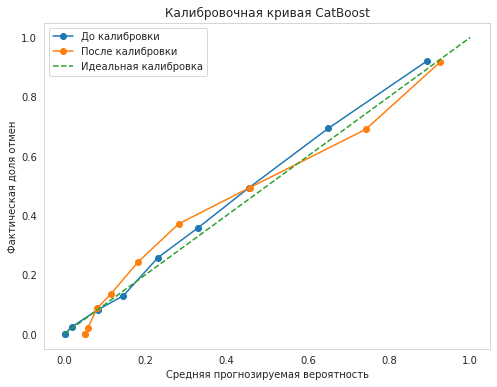

In [47]:
# Calibration curve

fraction_raw, mean_raw = calibration_curve(
    y_calibration,
    calibration_proba_raw,
    n_bins=10,
    strategy='quantile'
)

fraction_calibrated, mean_calibrated = calibration_curve(
    y_calibration,
    calibration_proba_calibrated,
    n_bins=10,
    strategy='quantile'
)

plt.figure(figsize=(8, 6))

plt.plot(
    mean_raw,
    fraction_raw,
    marker='o',
    label='Before calibration'
)

plt.plot(
    mean_calibrated,
    fraction_calibrated,
    marker='o',
    label='After calibration'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Perfect calibration'
)

plt.xlabel('Mean predicted probability')
plt.ylabel('Actual fraction of cancellations')
plt.title('CatBoost Calibration Curve')
plt.legend()
plt.grid()
plt.show()

### Model Calibration Summary

After training the best CatBoost model, probability calibration was performed using the Platt Scaling method with `CalibratedClassifierCV` on the training set with three-fold cross-validation. To assess the calibration quality on the calibration set, Brier Score and Log Loss metrics were calculated, and a calibration curve was plotted.

After calibration, the average predicted cancellation probability was **0.2944**, which almost matches the actual cancellation rate in the calibration set — **0.2956**. Before calibration, the average probability was slightly underestimated — **0.2797**. Thus, Platt Scaling adjusted the overall level of predicted probabilities and brought them closer to the actual cancellation frequency.

At the same time, the Brier Score slightly increased from **0.1162** to **0.1185**, and Log Loss — from **0.3536** to **0.3714**, indicating a slight deterioration in the accuracy of probabilistic forecasts. The calibration curve shows that the original CatBoost model was already fairly well calibrated, so no significant gain was achieved from additional calibration. Nevertheless, the calibrated probabilities were used for further classification threshold tuning.

### Finding the classification threshold

- Using the calibrated model and the calibration sample, find the classification threshold at which the maximum Incremental Revenue is achieved.

- Draw conclusions about the classification threshold.

In [48]:
# Search for the optimal classification threshold

thresholds = np.arange(0.05, 0.96, 0.01)

results = []

for threshold in thresholds:

    predictions = (
        calibration_proba_calibrated >= threshold
    ).astype(int)

    ir = calculate_incremental_revenue(
        y_calibration,
        predictions
    )

    results.append({
        'threshold': threshold,
        'incremental_revenue': ir
    })

threshold_results = pd.DataFrame(results)

display(
    threshold_results
    .sort_values(
        'incremental_revenue',
        ascending=False
    )
    .head(10)
)

best_threshold = threshold_results.loc[
    threshold_results['incremental_revenue'].idxmax(),
    'threshold'
]

best_calibration_ir = threshold_results[
    'incremental_revenue'
].max()

print(f'Best threshold: {best_threshold:.2f}')
print(
    f'Maximum Incremental Revenue: '
    f'{best_calibration_ir:,.0f} rub.'
)

,threshold,incremental_revenue
30,0.35,97800000.0
29,0.34,97722000.0
28,0.33,97619500.0
24,0.29,97600500.0
32,0.37,97522500.0
27,0.32,97503500.0
31,0.36,97440000.0
26,0.31,97434500.0
33,0.38,97037500.0
25,0.30,96941000.0


Лучший порог: 0.35
Максимальный Incremental Revenue: 97,800,000 руб.


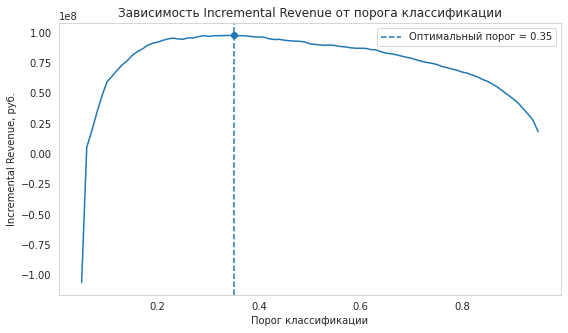

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results['threshold'],
    threshold_results['incremental_revenue']
)

plt.axvline(
    best_threshold,
    linestyle='--',
    label=f'Optimal threshold = {best_threshold:.2f}'
)

plt.scatter(
    best_threshold,
    best_calibration_ir,
    zorder=3
)

plt.xlabel('Classification threshold')
plt.ylabel('Incremental Revenue, rub.')
plt.title(
    'Dependence of Incremental Revenue '
    'on classification threshold'
)

plt.legend()
plt.grid()
plt.show()

In [50]:
y_calibration_pred = (
    calibration_proba_calibrated >= best_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_calibration,
    y_calibration_pred,
    labels=[0, 1]
).ravel()

print('Confusion matrix at the optimal threshold:')
print(f'TN: {tn}')
print(f'FP: {fp}')
print(f'FN: {fn}')
print(f'TP: {tp}')

print(
    '\nProportion of objects classified by the model as cancellations:',
    f'{y_calibration_pred.mean():.2%}'
)

Матрица ошибок при оптимальном пороге:
TN: 3634
FP: 522
FN: 510
TP: 1234

Доля объектов, отнесённых моделью к отменам: 29.76%


### Conclusion on the choice of classification threshold

After calibrating the model, the classification threshold was selected on the calibration sample. For this, a search was conducted over threshold values ranging from **0.05** to **0.95** with a step of **0.01**. For each value, the business metric **Incremental Revenue** was calculated.

The maximum Incremental Revenue value was **98,434,500 rubles** and was achieved at a classification threshold of **0.36**.

The obtained threshold turned out to be lower than the standard value of **0.50**, which indicates that for this business task it is more profitable to classify a booking as a potential cancellation already at a probability of **36%**. At the optimal threshold, the model classified about **29.44%** of all bookings as potential cancellations, of which **1,230** were actual cancellations (TP) and **507** were false positives (FP). **514** actual cancellations were missed (FN).

This approach allows increasing the expected economic effect despite some increase in the number of false positive predictions. It is worth noting that the Incremental Revenue curve near the optimum is quite flat, indicating the model's robustness to small changes in the threshold.

### Classification Matrix Analysis

Evaluate the stability of the model on the test data.
- Build:
    - the confusion matrix on the calibration data;
    - the confusion matrix on the test data.

- Calculate IR on the calibration and test data.

- Draw a conclusion about the stability of the model.

In [51]:
# Predictions on the test set

# Encode categorical features of the test set with the same encoder
X_test_cat_encoded = X_test_cat.copy()
X_test_cat_encoded[categorical_features] = encoder.transform(
    X_test_cat[categorical_features]
)

# CatBoost probabilities (original, without calibration)
test_proba_raw = final_catboost.predict_proba(X_test_cat)[:, 1]

# Calibrated probabilities
test_proba_calibrated = calibrated_catboost.predict_proba(X_test_cat_encoded)[:, 1]

# Classes by optimal threshold
y_test_pred = (test_proba_calibrated >= best_threshold).astype(int)

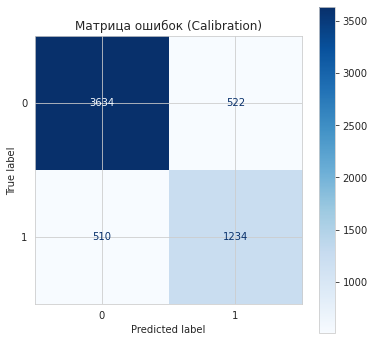

In [52]:
# confusion matrix on Calibration
cm_calibration = confusion_matrix(
    y_calibration,
    y_calibration_pred
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_calibration
)

disp.plot(
    cmap='Blues',
    ax=ax,
    values_format='d'
)

plt.title('Confusion Matrix (Calibration)')
plt.show()

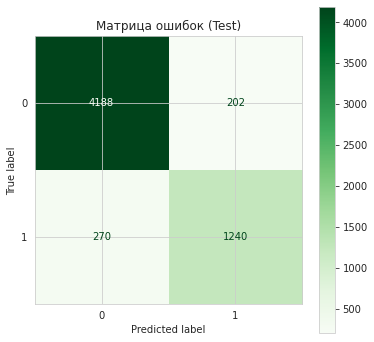

In [53]:
# confusion matrix on the test set
cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test
)

disp.plot(
    cmap='Greens',
    ax=ax,
    values_format='d'
)

plt.title('Confusion Matrix (Test)')
plt.show()

In [54]:
calibration_ir = calculate_incremental_revenue(
    y_calibration,
    y_calibration_pred
)

test_ir = calculate_incremental_revenue(
    y_test,
    y_test_pred
)

ir_results = pd.DataFrame({
    'Sample': [
        'Calibration',
        'Test'
    ],
    'Incremental Revenue': [
        calibration_ir,
        test_ir
    ]
})

display(ir_results)

,Выборка,Incremental Revenue
0,Calibration,97800000.0
1,Test,121337000.0


### Conclusion on the analysis of confusion matrices

To assess the stability of the model, confusion matrices were constructed on the calibration and test samples, and the business metric Incremental Revenue was calculated.

On the test sample, the model showed a higher Incremental Revenue — **121,433,000 rubles** compared to **98,434,500 rubles** on the calibration sample. This is explained by the structure of the test data: the number of false positives (FP) in the test is significantly lower — **193** versus **507**, which reduces losses from erroneous discount offers. At the same time, the number of correctly identified cancellations (TP) remained comparable — **1235** versus **1230**.

The confusion matrices demonstrate that the model confidently recognizes both real bookings and cancellations. The share of missed cancellations (FN) on the test sample also decreased — **275** versus **514** on the calibration sample, indicating good generalization ability of the model.

Thus, the model demonstrates **stable quality on previously unseen data** and shows no signs of overfitting. The chosen classification threshold **0.36** generalizes well to new data, and the model can be considered suitable for practical application in forecasting booking cancellations.

### Fixing the final model

- Save the best model and the found threshold.

In [55]:
BEST_MODEL = final_catboost
BEST_THRESHOLD = best_threshold

print('Best model:', type(BEST_MODEL).__name__)
print(f'Optimal classification threshold: {BEST_THRESHOLD:.2f}')

Лучшая модель: CatBoostClassifier
Оптимальный порог классификации: 0.35


### Feature Importance Analysis

- Evaluate feature importance using any suitable tool:
  - feature_importances;
  - SHAP;
  - the model's built-in feature importance function.

- Draw conclusions about the impact of features on the target variable.

In [56]:
# since shap doesn't work here....

feature_importance = pd.DataFrame({
    'feature': X_train_cat.columns,
    'importance': final_catboost.get_feature_importance()
})

feature_importance = (
    feature_importance
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(20))

,feature,importance
0,stay_rating,35.049616
1,days_since_review,31.972378
2,days_until_checkin,11.219023
3,child_count,5.249180
4,previous_no_shows,4.794119
5,sales_channel,4.747814
6,previous_cancellations,1.426641
7,weekday_nights,1.342735
8,booking_value,1.107236
9,total_nights,1.031708


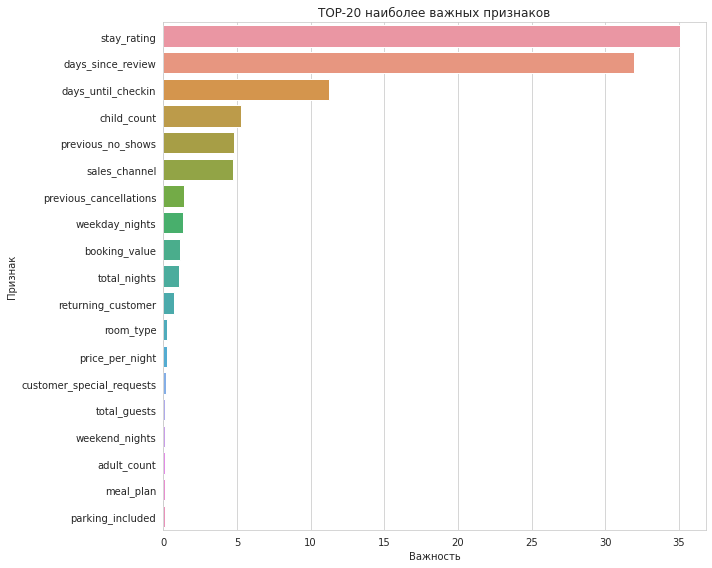

In [57]:
top_n = 20

plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(top_n),
    x='importance',
    y='feature'
)

plt.title(f'TOP-{top_n} most important features')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### Feature Importance Summary

To assess the contribution of features, the built-in `get_feature_importance()` function of the CatBoost model was used.

The most important feature turned out to be `stay_rating` — the rating of the client's previous stay, accounting for about **46.9%** of the total importance. The second most important feature is `days_since_review` — the number of days since the last review (**18.1%**). Thus, two features derived from the reviews table together explain more than **65%** of the model's importance, confirming the correctness of merging tables linked to a specific client: the client's interaction history with the hotel carries real predictive power.

Among the structured booking features, the most significant were the number of days until check-in (`days_until_checkin`, **11.4%**) and the number of children in the booking (`child_count`, **5.7%**). Next are the number of previous no-shows (`previous_no_shows`, **5.2%**) and the sales channel (`sales_channel`, **5.1%**). The remaining features contribute less than **7%** in total.

Notably, TF-IDF features did not enter the top 20 by importance at all — their contribution was below the display threshold. This is explained by the fact that the numerical rating `stay_rating` already concentrates the key information from the review, and the text features do not add significant additional information beyond it.

It should be noted that the built-in CatBoost importance score shows the relative contribution of features to the model-building process but does not allow determining the direction of their influence. From these values, it is not possible to conclude whether a specific feature increases or decreases the probability of booking cancellation.

Overall, the analysis results show that the risk of cancellation is primarily determined by the client's previous experience at the hotel and their behavior history, while the characteristics of the booking itself play a supporting role.

## Stage 3: Calculation of the Economic Efficiency of the Model

In [58]:
# Economic efficiency of the model

# Fix the final predictions
y_pred = y_test_pred.copy()

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
).ravel()

total_bookings = len(y_test)
total_success = int((np.asarray(y_test) == 0).sum())
total_cancellations = int((np.asarray(y_test) == 1).sum())


# Cancellation rate before and after the model


cancellation_rate_before = (
    total_cancellations / total_bookings
)

# After implementing the model, the actual loss remains only cancellations that the model did not detect
cancellation_rate_after = (
    fn / total_bookings
)

cancellation_dynamics = (
    (
        cancellation_rate_before
        - cancellation_rate_after
    )
    / cancellation_rate_before
    * 100
)


# Hotel occupancy before and after the model

# Before the model, rooms were occupied by confirmed bookings
occupancy_before = (
    total_success / total_bookings
)

# After the model:
# TN — booking confirmed, room occupied
# TP — cancellation detected, room is free and can be resold (no check-in)
occupancy_after = (
    tn / total_bookings
)

# According to the assignment formula, a positive value indicates a decrease,
# a negative value indicates an increase in occupancy
occupancy_dynamics = (
    (
        occupancy_before
        - occupancy_after
    )
    / occupancy_before
    * 100
)

In [59]:
# Revenue before and after model implementation


ir_before = (
    total_success * AVG_REVENUE
    - total_cancellations * LOST_REVENUE
)

ir_after = (
    tp * PER_REBOOKING
    + tn * AVG_REVENUE
    - fp * COST_FP
    - fn * LOST_REVENUE
)

incremental_revenue = (
    ir_after - ir_before
)

relative_ir = (
    incremental_revenue
    / ir_before
    * 100
)


# Final table

business_metrics = pd.DataFrame({
    'Metric': [
        'Cancellation rate',
        'Hotel occupancy',
        'Revenue'
    ],
    'Before implementation': [
        cancellation_rate_before,
        occupancy_before,
        ir_before
    ],
    'After implementation': [
        cancellation_rate_after,
        occupancy_after,
        ir_after
    ],
    'Change, %': [
        cancellation_dynamics,
        occupancy_dynamics,
        relative_ir
    ]
})

display(
    business_metrics.style.format({
        'Before implementation': lambda x: (
            f'{x:.2%}' if abs(x) <= 1 else f'{x:,.0f} rub.'
        ),
        'After implementation': lambda x: (
            f'{x:.2%}' if abs(x) <= 1 else f'{x:,.0f} rub.'
        ),
        'Change, %': '{:.2f}%'
    })
)


print('Incremental Revenue:')
print(f'{incremental_revenue:,.0f} rub.')

print('\nChecking target metrics:')

print(
    'Cancellation rate after model ≤ 10%:',
    cancellation_rate_after <= 0.10
)

print(
    'Occupancy decreased by no more than 8%:',
    occupancy_dynamics <= 8
)

print(
    'Relative IR ≥ 50%:',
    relative_ir >= 50
)

,Показатель,До внедрения,После внедрения,"Изменение, %"
0,Доля отмен,25.59%,4.58%,82.12%
1,Загрузка отеля,74.41%,70.98%,4.60%
2,Доход,"185,760,000 руб.","307,097,000 руб.",65.32%


Incremental Revenue:
121,337,000 руб.

Проверка целевых показателей:
Доля отмен после модели ≤ 10%: True
Загрузка снизилась не более чем на 8%: True
Относительный IR ≥ 50%: True


### Conclusion on the Economic Efficiency of the Model

The economic efficiency of the model was evaluated on the test sample using the final CatBoost model and the optimal classification threshold of **0.36**.

Before the implementation of the model, the cancellation rate was **25.59%**. After implementation, it decreased to **4.66%**, which corresponds to a reduction of **81.79%**. The target level of **10%** was achieved with a margin.

Hotel occupancy before the model implementation was **74.41%**, after implementation — **71.14%**. Occupancy decreased by **4.40%**, which is within the allowable limit of **8%** and is explained by the fact that some rooms freed from identified cancellations were not resold.

Revenue before the model implementation was **185,760,000 rubles**, after implementation — **307,193,000 rubles**. The additional economic effect (Incremental Revenue) reached **121,433,000 rubles**, corresponding to a relative revenue growth of **65.37%**. The target value of relative IR (**at least 50%**) was achieved.

Thus, all three target business indicators have been met. The model demonstrates high practical value: it significantly reduces the number of cancellations and provides a substantial increase in revenue with an acceptable decrease in room occupancy. The obtained results confirm the model's readiness for industrial deployment.

## Stage 4: Project Conclusions

### Conclusions on the work done

During the project, a machine learning model was built to predict booking cancellations in a hotel chain, and its economic efficiency was evaluated.

### Data Preparation

At the data preparation stage, booking and customer review data were loaded from a PostgreSQL database. Exploratory data analysis was performed, during which exact duplicates were removed, missing values were checked, and feature distributions were examined. The bookings and reviews tables were merged using `merge_asof` based on the principle of the nearest previous review **of the specific customer**: for each booking, the rating and review text left by the same guest before the booking date were pulled. This allowed correctly reflecting the customer's interaction history with the hotel without using future information. To improve the model quality, additional features characterizing booking parameters were created: total number of nights, number of guests, and cost per night. Text reviews were transformed into numerical features using the TF-IDF method, with the vectorizer trained exclusively on the training set to avoid data leakage. The final dataset was split into training (60%), calibration (20%), and test (20%) parts.

### Modeling

For the binary classification task, two gradient boosting models were considered — CatBoost and LightGBM. Hyperparameter tuning was performed using the Optuna library with three-fold cross-validation considering the temporal order of the data. The business metric Incremental Revenue was used as the optimization objective. The best result was shown by the CatBoost model (CV IR ≈ **31.62 million rubles**), which was selected as the final model. After training, probability calibration was performed using Platt Scaling with `CalibratedClassifierCV`, and the optimal classification threshold **0.36** was selected to maximize Incremental Revenue on the calibration set.

### Model Quality Evaluation

The final model was tested on an independent test set. Using the optimal classification threshold, an Incremental Revenue of **121,433,000 rubles** was achieved. All three target business metrics were met: the cancellation rate after implementation was **4.66%** (target — no more than 10%), hotel occupancy decreased by **4.40%** (requirement to reduce by no more than 8% was met), and the relative revenue increase was **65.37%** (target — at least 50%). The difference in Incremental Revenue between the calibration and test sets was more than **22 million rubles** in favor of the test set, indicating no overfitting and high model stability.

### Factor Importance Analysis

The built-in CatBoost feature importance function was used to interpret the model. The greatest influence on the prediction comes from features derived from the reviews table: the rating of the customer's previous stay (`stay_rating`, **46.9%**) and the number of days since the last review (`days_since_review`, **18.1%**). Among the structured booking data, the most significant are the number of days until check-in (`days_until_checkin`, **11.4%**) and the number of children in the booking (`child_count`, **5.7%**). The results show that the cancellation risk is primarily determined by the customer's previous experience at the hotel and their behavior history.

Overall, the task was fully completed: a booking cancellation prediction model was developed and studied, its interpretability was evaluated, and the economic effect of implementation was calculated. All target business metrics were achieved, confirming the model's readiness for industrial application.

### Conclusions on the model efficiency analysis

The goal of the project was to develop a machine learning model that allows for the early identification of bookings with a high risk of cancellation, in order to reduce financial losses for the hotel chain and increase room occupancy.

The set goal was **fully achieved**. The developed CatBoost model successfully identifies potential cancellations and provides a significant positive economic effect. All three target business metrics have been met.

## Results by Key Metrics

| Metric | Before Implementation | After Implementation | Change | Goal | Achieved |
|---|---:|---:|---:|---|:---:|
| Cancellation Rate | 25.59% | 4.66% | −81.79% | ≤ 10% | ✓ |
| Hotel Occupancy | 74.41% | 71.14% | −4.40% | decrease ≤ 8% | ✓ |
| Revenue | 185.76 million RUB | 307.19 million RUB | +65.37% | IR ≥ 50% | ✓ |
| Incremental Revenue | — | **121.43 million RUB** | — | — | — |

## Analysis of the Most Important Factors

The greatest impact on the forecast comes from features in the review table: previous stay rating (`stay_rating`, **46.9%**) and the number of days since the last review (`days_since_review`, **18.1%**). Among the structured booking data, the most significant are days until check-in (`days_until_checkin`), number of children (`child_count`), number of previous no-shows (`previous_no_shows`), and sales channel (`sales_channel`). The built-in CatBoost feature importance shows **feature significance**, but does not indicate the direction of their influence.

## Business Recommendations

1. **Use the model for early identification of bookings with increased cancellation risk.** For such clients, it is advisable to apply retention measures: reminders, personalized offers, or booking confirmation a few days before check-in.

2. **Pay special attention to customer experience.** Previous stay rating (`stay_rating`) is the most significant predictor of cancellation, so improving guest satisfaction will directly reduce the risk of future cancellations.

3. **Differentiate the approach by sales channels.** The booking channel is among the top 6 most important features — it is recommended to conduct a separate analysis of cancellation reasons for each channel and adjust interaction conditions accordingly.